# Vanilla vs noMHC ProteinMPNN — native-backbone recovery at T=0.3 (companion to notebook 17)

Same ablation as notebook 17, same two native crystal backbones (6AM5 = GIG `SMLGIGIVPV`, 6AMU = DRG
`MMWDRGLGMM`, full complex context — HLA-A\*02 chain A, β2m chain B, TCR chains D+E all **fixed**,
only the 10-mer peptide chain C **designed**) — but at **T=0.3** instead of T=0.1, and 10,000
sequences/crystal instead of 50,000:

- **vanilla** — `model_name=v_48_020` (`outputs/native_T03_10k/seqs/vanilla_{pid}.fa`, complete, 10,001/crystal).
- **noMHC** — `model_name=proteinmpnn_nomhc` (`outputs/native_T03_10k/seqs/nomhc_{pid}.fa`, may be in
  progress — see data-status cell).

This isolates model weights as the only variable, exactly like notebook 17. Notebook 17's
cross-references to the de-novo ladder backbones (07) and the historical noMHC baseline (12) are
**not** repeated here — those ran at T=0.1, and comparing them against this T=0.3 run would confound
temperature with model identity. Sections:
1. Load + data-status inventory
2. Basic stats & duplication
3. Recovery — overall identity & per-position, vanilla vs noMHC
4. Amino-acid composition & distribution shift (Δ vanilla − noMHC)
5. Sequence logos, side by side
6. Memorization probe — exact/near-exact recovery, gap by position (vanilla vs noMHC only, no
   cross-notebook temperature-mismatched comparisons)
7. Summary & verdict

In [2]:
from pathlib import Path
import re, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except Exception:
    display = print
warnings.filterwarnings("ignore")
sns.set_context("notebook"); sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = Path("/home/ubuntu/if-mhc")
FIGDIR = ROOT / "outputs/analysis/figures_nomhc_vs_vanilla_T03"; FIGDIR.mkdir(parents=True, exist_ok=True)

AA = list("ACDEFGHIKLMNPQRSTVWY")
AA_IDX = {a: i for i, a in enumerate(AA)}
L = 10
NAT = {"6AM5": "SMLGIGIVPV", "6AMU": "MMWDRGLGMM"}   # GIG, DRG
ANCHORS = [2, 10]                                     # 1-based P2 / PΩ(P10), HLA-A*02 anchors
CRYSTALS = ["6AM5", "6AMU"]
TEMP = 0.3; NSEQ_TARGET = 10000

CAMPAIGN_DIR = ROOT / "outputs/native_T03_10k"
MODEL_COLOR = {"vanilla": "#1f77b4", "noMHC": "#d62728"}

## 1. Load sequences

In [3]:
def load_fasta(path, L=L):
    '''Parse a ProteinMPNN FASTA. First record (no "sample=") is native/reference; rest are designs.'''
    p = Path(path)
    if not p.exists():
        return pd.DataFrame(columns=["peptide","score","global_score","seq_recovery","T","sample","model_name"])
    lines = p.read_text().splitlines()
    rows = []
    for i in range(0, len(lines)-1, 2):
        h, s = lines[i], lines[i+1].strip()
        if not h.startswith(">") or "sample=" not in h or len(s) != L:
            continue
        d = dict(re.findall(r'(\w+)=([-\d.]+)', h))
        rows.append({"peptide": s, "score": float(d.get("score","nan")),
                     "global_score": float(d.get("global_score","nan")),
                     "seq_recovery": float(d.get("seq_recovery","nan")),
                     "T": float(d.get("T","nan")), "sample": int(float(d.get("sample",0)))})
    return pd.DataFrame(rows)

def n_records(path):
    p = Path(path)
    if not p.exists(): return 0
    return sum(1 for l in open(p) if l.startswith(">") and "sample=" in l)

def resolve_fasta(weights, pid):
    '''run_native_T03_10k.sh renames seqs/<pid>.fa -> seqs/<weights>_<pid>.fa on completion. Mid-run,
    the bare <pid>.fa is what's actively being written -- fall back to it if the tagged file isn't
    there yet, so this notebook is safe to run while the campaign is still in progress.'''
    tagged = CAMPAIGN_DIR / f"seqs/{weights}_{pid}.fa"
    bare = CAMPAIGN_DIR / f"seqs/{pid}.fa"
    if tagged.exists():
        return tagged, n_records(tagged), "complete" if n_records(tagged) >= NSEQ_TARGET else f"in progress ({n_records(tagged):,})"
    if bare.exists():
        return bare, n_records(bare), f"in progress, not yet renamed ({n_records(bare):,})"
    return tagged, 0, "not started"

frames = []
status = {}
for pid in CRYSTALS:
    for weights in ["vanilla", "nomhc"]:
        path, n, note = resolve_fasta(weights, pid)
        d = load_fasta(path); d["model"] = "vanilla" if weights == "vanilla" else "noMHC"; d["crystal"] = pid
        frames.append(d)
        status[(d["model"].iloc[0] if len(d) else ("vanilla" if weights=="vanilla" else "noMHC"), pid)] = (path, len(d), note)

df = pd.concat(frames, ignore_index=True)
df["native"] = df.crystal.map(NAT)
pos_cols = [f"p{i+1}" for i in range(L)]
df[pos_cols] = df.peptide.apply(lambda s: pd.Series(list(s)))
print(f"loaded {len(df):,} rows across {df.model.nunique()} models x {df.crystal.nunique()} crystals")

loaded 40,000 rows across 2 models x 2 crystals


### Data-status inventory — what this run actually has loaded

In [4]:
inv = pd.DataFrame([
    {"model": m, "crystal": p, "source": str(path.relative_to(ROOT)), "n_designs": n, "status": note}
    for (m, p), (path, n, note) in status.items()
]).sort_values(["crystal","model"])
display(inv)
if inv.n_designs.min() < NSEQ_TARGET:
    print(f"NOTE: at least one target is not yet at the {NSEQ_TARGET:,} target -- all comparisons below use")
    print("whatever is currently on disk. Re-run this notebook later for final numbers.")

,model,crystal,source,n_designs,status
1,noMHC,6AM5,outputs/native_T03_10k/seqs/nomhc_6AM5.fa,10000,complete
0,vanilla,6AM5,outputs/native_T03_10k/seqs/vanilla_6AM5.fa,10000,complete
3,noMHC,6AMU,outputs/native_T03_10k/seqs/nomhc_6AMU.fa,10000,complete
2,vanilla,6AMU,outputs/native_T03_10k/seqs/vanilla_6AMU.fa,10000,complete


## 2. Basic stats & duplication, per model x crystal

,crystal,model,n,n_unique,pct_unique,native_exact_hits,mean_score,median_score
0,6AM5,noMHC,10000.0,887.0,8.9,0.0,0.8853,0.8688
1,6AM5,vanilla,10000.0,608.0,6.1,0.0,0.8533,0.8219
2,6AMU,noMHC,10000.0,811.0,8.1,0.0,0.8795,0.8642
3,6AMU,vanilla,10000.0,453.0,4.5,0.0,0.8037,0.7910


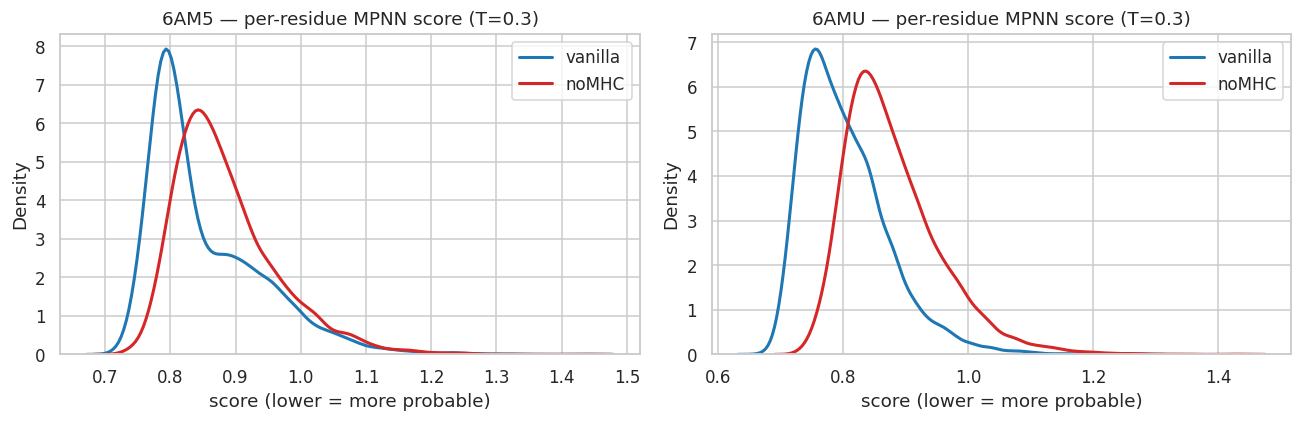

In [5]:
def basic_stats(sub):
    n = len(sub); u = sub.peptide.nunique()
    exact = int((sub.peptide == sub.native.iloc[0]).sum()) if n else 0
    return pd.Series({"n": n, "n_unique": u, "pct_unique": round(100*u/n, 1) if n else np.nan,
                       "native_exact_hits": exact,
                       "mean_score": round(sub.score.mean(), 4) if n else np.nan,
                       "median_score": round(sub.score.median(), 4) if n else np.nan})

stats = df.groupby(["crystal","model"]).apply(basic_stats).reset_index()
display(stats)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, pid in enumerate(CRYSTALS):
    for m in ["vanilla","noMHC"]:
        s = df[(df.crystal==pid)&(df.model==m)].score.dropna()
        if len(s): sns.kdeplot(s, ax=ax[i], color=MODEL_COLOR[m], label=m, lw=2)
    ax[i].set_title(f"{pid} — per-residue MPNN score (T={TEMP})"); ax[i].set_xlabel("score (lower = more probable)")
    ax[i].legend()
plt.tight_layout(); plt.savefig(FIGDIR/"score_distributions.png", bbox_inches="tight"); plt.show()

## 3. Recovery vs native — overall identity & per-position, vanilla vs noMHC

,crystal,model,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
0,6AM5,vanilla,1.3,0.5,87.3,100.0,9.5,100.0,38.5,6.3,99.2,50.6
1,6AM5,noMHC,0.0,5.0,6.2,100.0,84.2,100.0,73.6,12.0,99.9,1.0
2,6AMU,vanilla,99.8,0.2,0.0,99.6,0.0,100.0,70.6,99.6,0.1,0.1
3,6AMU,noMHC,99.9,0.0,0.0,99.8,0.2,100.0,13.5,83.6,0.0,0.1


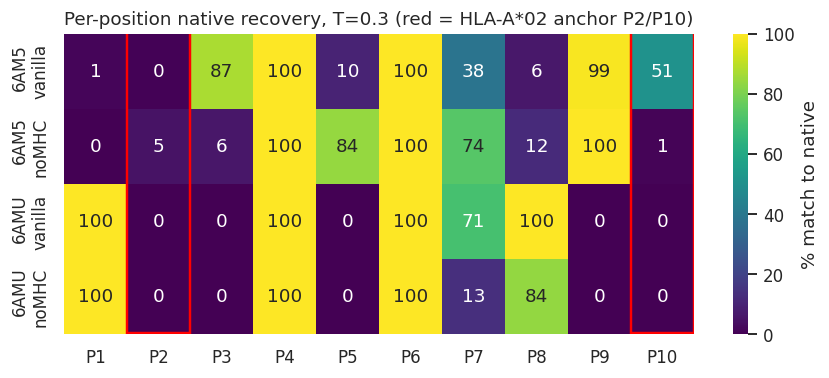

In [6]:
def perpos_recovery(seqs, nat):
    if len(seqs) == 0: return np.full(L, np.nan)
    P = np.array([list(s) for s in seqs])
    return (P == np.array(list(nat))).mean(0) * 100

rows = []
for pid in CRYSTALS:
    nat = NAT[pid]
    for m in ["vanilla","noMHC"]:
        seqs = df[(df.crystal==pid)&(df.model==m)].peptide.values
        rec = perpos_recovery(seqs, nat)
        rows.append({"crystal": pid, "model": m, **{f"P{i+1}": rec[i] for i in range(L)}})
perpos_df = pd.DataFrame(rows)
display(perpos_df.round(1))

M = perpos_df[[f"P{i+1}" for i in range(L)]].values
labels = [f"{r.crystal}\n{r.model}" for r in perpos_df.itertuples()]
fig, ax = plt.subplots(figsize=(8, 0.55*len(M)+1.4))
sns.heatmap(M, annot=True, fmt=".0f", cmap="viridis", vmin=0, vmax=max(40, np.nanmax(M)),
            xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=labels,
            cbar_kws={"label":"% match to native"}, ax=ax)
for a in ANCHORS:
    ax.add_patch(plt.Rectangle((a-1, -0.02), 1, len(M), fill=False, ec="red", lw=1.6))
ax.set_title(f"Per-position native recovery, T={TEMP} (red = HLA-A*02 anchor P2/P10)")
plt.tight_layout(); plt.savefig(FIGDIR/"perposition_recovery.png", bbox_inches="tight"); plt.show()

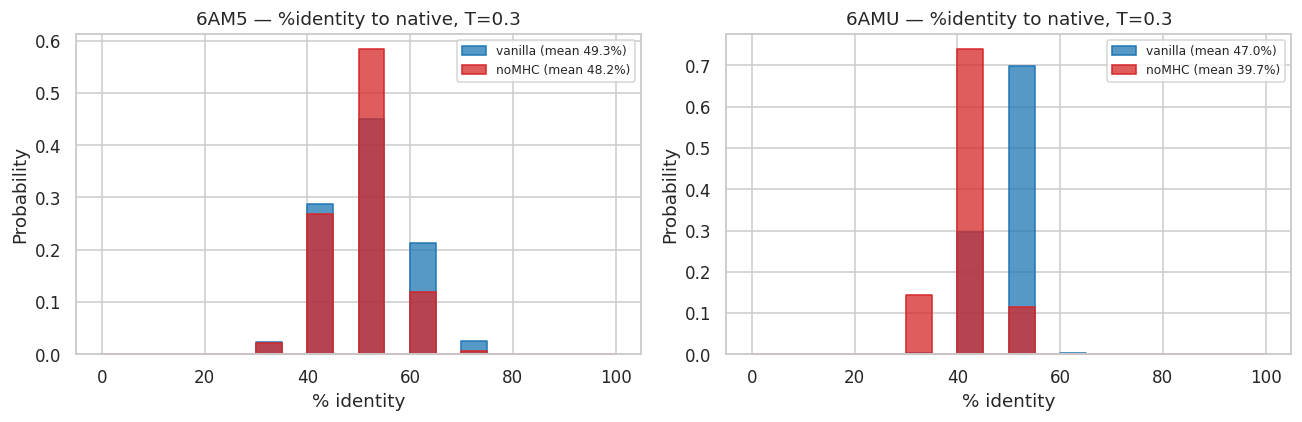

mean  median   std
crystal model                       
6AM5    noMHC    48.19    50.0  6.85
        vanilla  49.31    50.0  8.38
6AMU    noMHC    39.72    40.0  5.12
        vanilla  47.01    50.0  4.71

In [7]:
P_all = {(pid,m): np.array([list(s) for s in df[(df.crystal==pid)&(df.model==m)].peptide.values])
         for pid in CRYSTALS for m in ["vanilla","noMHC"]}
for pid in CRYSTALS:
    nat = np.array(list(NAT[pid]))
    for m in ["vanilla","noMHC"]:
        P = P_all[(pid,m)]
        if len(P)==0: continue
        ham = (P != nat).sum(1)
        df.loc[(df.crystal==pid)&(df.model==m), "hamming"] = ham
        df.loc[(df.crystal==pid)&(df.model==m), "identity"] = 100*(1 - ham/L)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, pid in enumerate(CRYSTALS):
    for m in ["vanilla","noMHC"]:
        s = df[(df.crystal==pid)&(df.model==m)].identity.dropna()
        if len(s): sns.histplot(s, bins=np.arange(0,101,5), ax=ax[i], color=MODEL_COLOR[m],
                                 label=f"{m} (mean {s.mean():.1f}%)", element="step", stat="probability")
    ax[i].set_title(f"{pid} — %identity to native, T={TEMP}"); ax[i].set_xlabel("% identity"); ax[i].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGDIR/"identity_distributions.png", bbox_inches="tight"); plt.show()
df.groupby(["crystal","model"]).identity.agg(["mean","median","std"]).round(2)

In [8]:
for apos in ANCHORS:
    col = f"p{apos}"
    for pid in CRYSTALS:
        nat_res = NAT[pid][apos-1]
        for m in ["vanilla","noMHC"]:
            sub = df[(df.crystal==pid)&(df.model==m)]
            if len(sub)==0: continue
            frac = (sub[col]==nat_res).mean()*100
            print(f"P{apos} anchor, {pid} ({m}): native={nat_res} recovered in {frac:.1f}% of designs")
print("(full anchor composition table shown in section 4's per-position heatmaps)")

P2 anchor, 6AM5 (vanilla): native=M recovered in 0.5% of designs
P2 anchor, 6AM5 (noMHC): native=M recovered in 5.0% of designs
P2 anchor, 6AMU (vanilla): native=M recovered in 0.2% of designs
P2 anchor, 6AMU (noMHC): native=M recovered in 0.0% of designs
P10 anchor, 6AM5 (vanilla): native=V recovered in 50.5% of designs
P10 anchor, 6AM5 (noMHC): native=V recovered in 1.1% of designs
P10 anchor, 6AMU (vanilla): native=M recovered in 0.1% of designs
P10 anchor, 6AMU (noMHC): native=M recovered in 0.1% of designs
(full anchor composition table shown in section 4's per-position heatmaps)


## 4. Amino-acid composition & distribution shift (Δ = vanilla − noMHC)

Same native backbone, same T=0.3 — any AA-frequency difference here is attributable **only** to the
model weights.

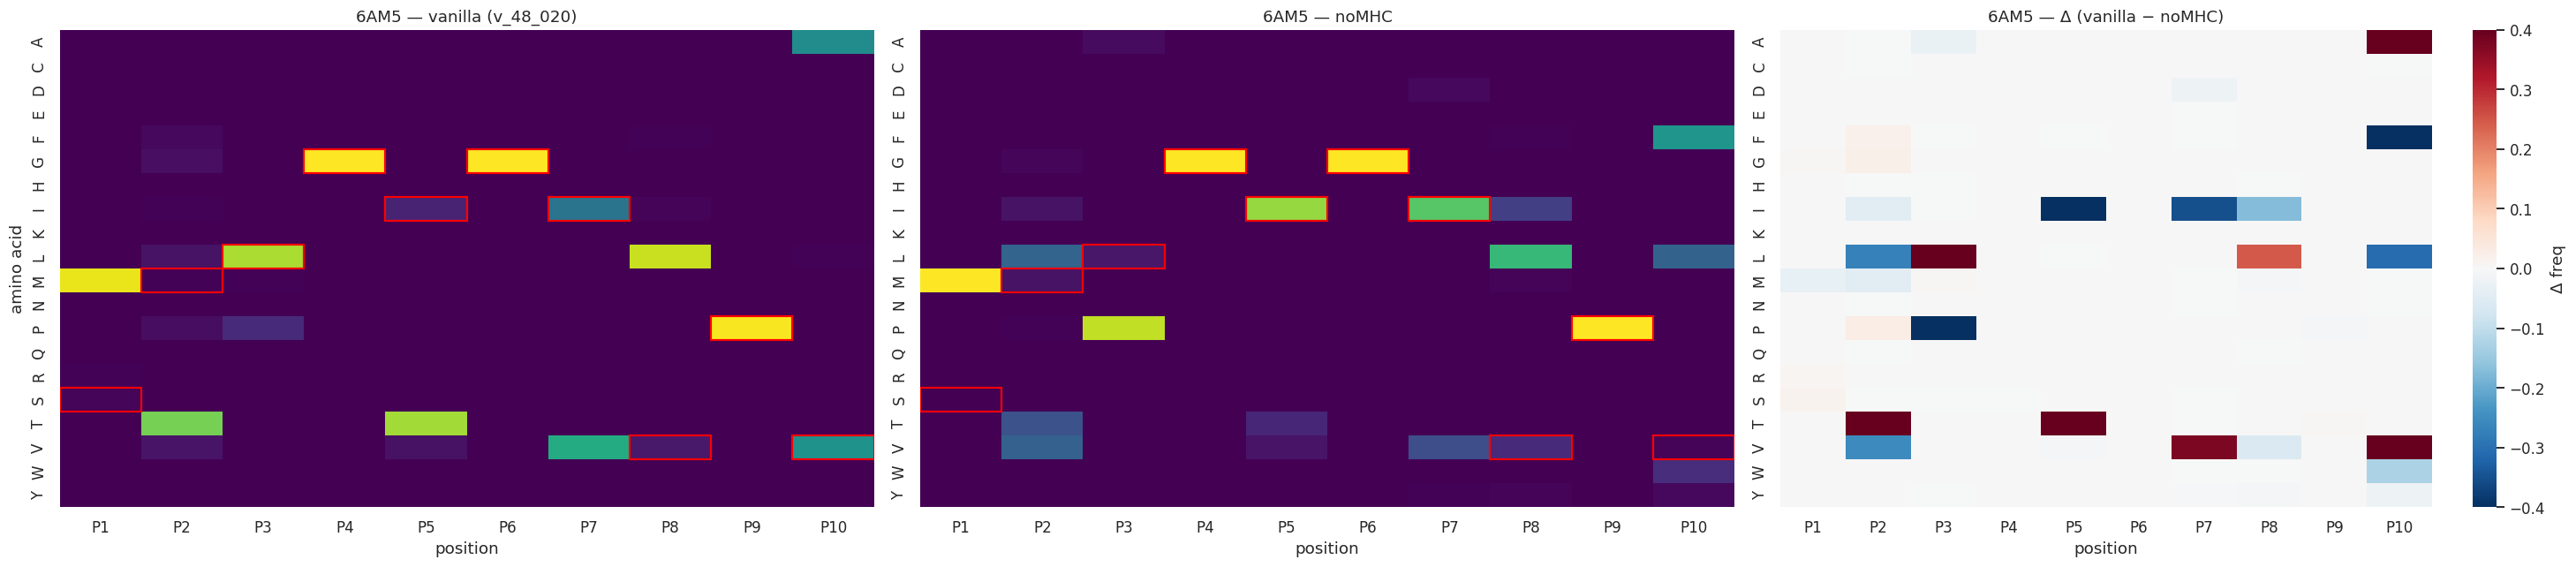

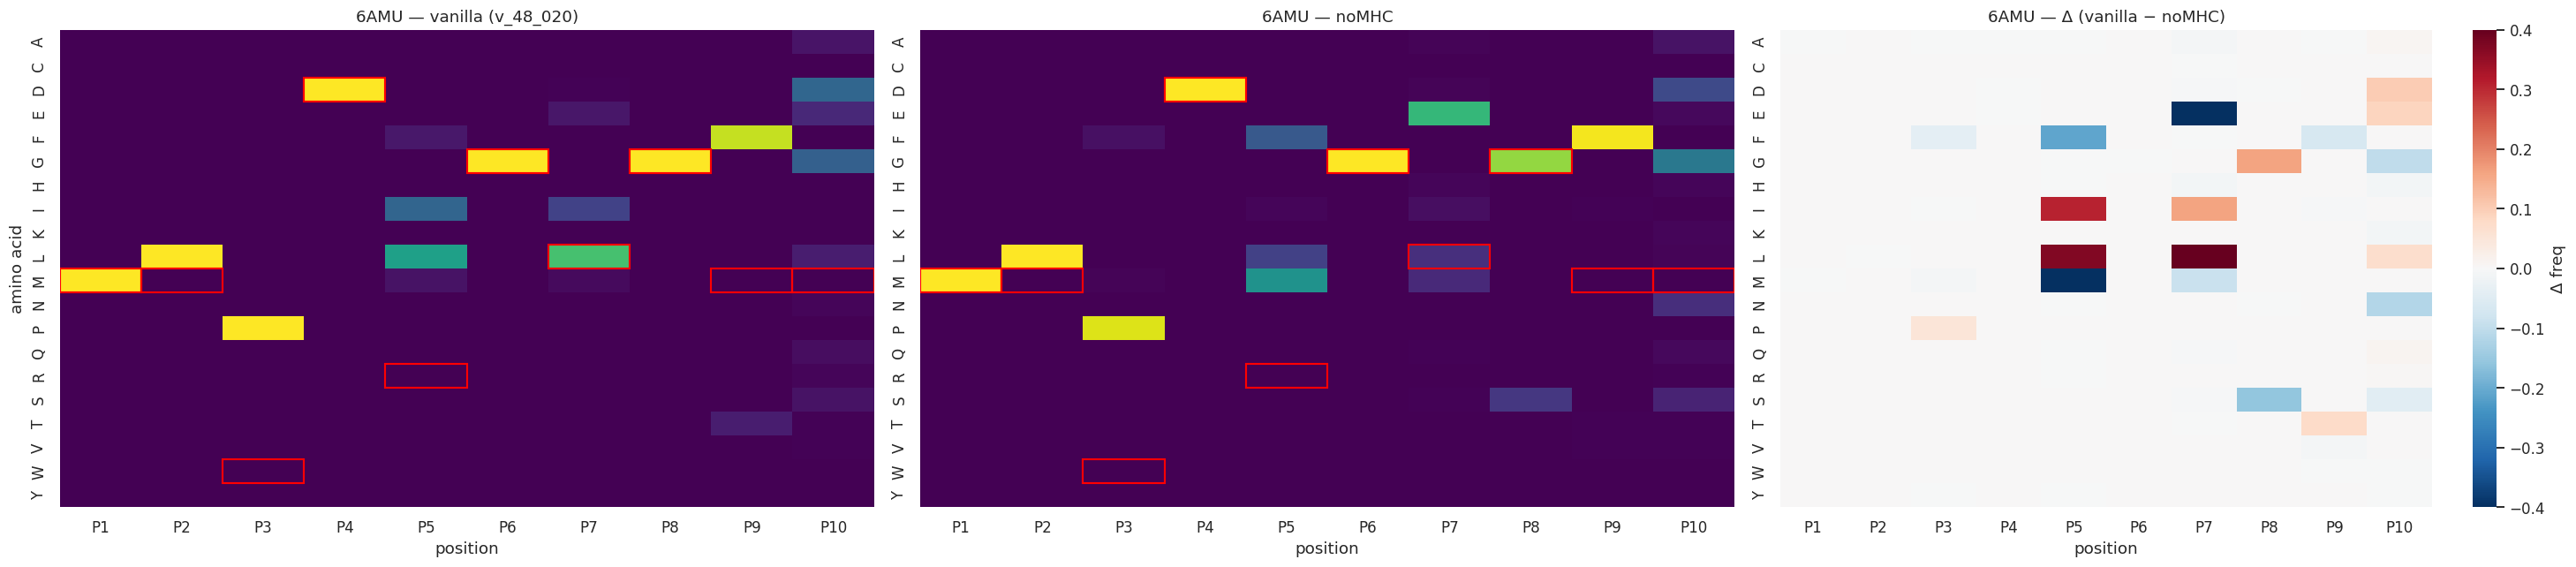

In [9]:
def freq_matrix(seqs, L=L):
    M = np.zeros((L, len(AA)))
    for s in seqs:
        for i, c in enumerate(s):
            if c in AA_IDX: M[i, AA_IDX[c]] += 1
    M /= np.clip(M.sum(1, keepdims=True), 1, None)
    return pd.DataFrame(M, columns=AA, index=list(range(L)))

for pid in CRYSTALS:
    nat = NAT[pid]
    fV = freq_matrix(df[(df.crystal==pid)&(df.model=="vanilla")].peptide.values)
    fN = freq_matrix(df[(df.crystal==pid)&(df.model=="noMHC")].peptide.values)
    fig, ax = plt.subplots(1, 3, figsize=(2.1*L+6, 6))
    for a, (M, t) in zip(ax[:2], [(fV,"vanilla (v_48_020)"), (fN,"noMHC")]):
        sns.heatmap(M.T, cmap="viridis", vmin=0, vmax=1, ax=a, cbar=False,
                    xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=AA)
        for i,c in enumerate(nat):
            if c in AA_IDX: a.add_patch(plt.Rectangle((i,AA_IDX[c]),1,1,fill=False,ec="red",lw=1.4))
        a.set_title(f"{pid} — {t}"); a.set_xlabel("position")
    sns.heatmap((fV-fN).T, cmap="RdBu_r", center=0, vmin=-0.4, vmax=0.4, ax=ax[2],
                xticklabels=[f"P{i+1}" for i in range(L)], yticklabels=AA, cbar_kws={"label":"Δ freq"})
    ax[2].set_title(f"{pid} — Δ (vanilla − noMHC)"); ax[2].set_xlabel("position")
    ax[0].set_ylabel("amino acid")
    plt.tight_layout(); plt.savefig(FIGDIR/f"aa_freq_delta_{pid}.png", bbox_inches="tight"); plt.show()

## 5. Sequence logos, side by side

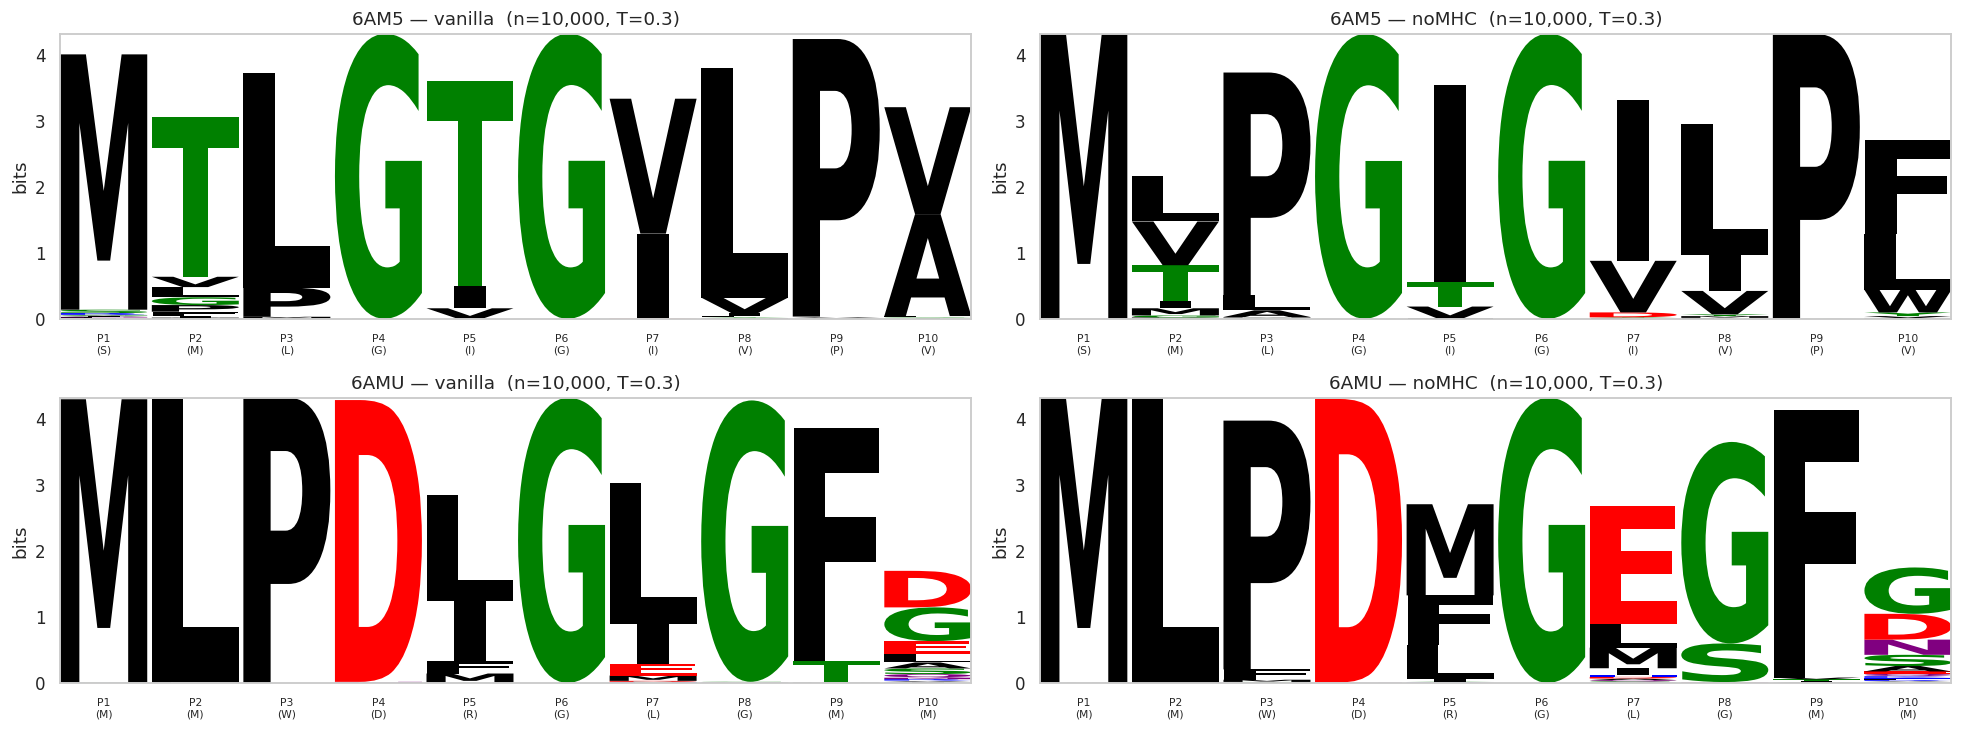

In [14]:
import logomaker
fig, axes = plt.subplots(2, 2, figsize=(max(6,L*0.9)*2, 3.4*2))
for r, pid in enumerate(CRYSTALS):
    nat = NAT[pid]
    for c, m in enumerate(["vanilla","noMHC"]):
        seqs = df[(df.crystal==pid)&(df.model==m)].peptide.values
        ax = axes[r][c]
        if len(seqs) == 0:
            ax.set_axis_off(); ax.set_title(f"{pid} {m} (no data yet)"); continue
        fmat = freq_matrix(seqs)
        info = logomaker.transform_matrix(fmat.copy(), from_type="probability", to_type="information")
        logomaker.Logo(info, ax=ax, color_scheme="chemistry")
        ax.set_ylim(0, 4.32)
        ax.set_xticks(range(L)); ax.set_xticklabels([f"P{i+1}\n({nat[i]})" for i in range(L)], fontsize=7)
        ax.set_title(f"{pid} — {m}  (n={len(seqs):,}, T={TEMP})"); ax.set_ylabel("bits"); ax.grid(False)
plt.tight_layout(); plt.savefig(FIGDIR/"sequence_logos_side_by_side.png", bbox_inches="tight"); plt.show()

## 6. Memorization probe (vanilla vs noMHC only — no cross-temperature references)

Same logic as notebook 17: 6AM5/6AMU were deposited 2017 (pre-dates ProteinMPNN), so vanilla weights
are a *plausible* trainset member; `proteinmpnn_nomhc` is guaranteed never to have seen any MHC/TCR
structure. A vanilla-noMHC gap concentrated on these backbones specifically is the memorization
fingerprint. Unlike notebook 17, this section does NOT cross-reference the de-novo ladder backbones
or the historical noMHC baseline (both T=0.1) — mixing those in here would confound temperature with
model identity.

In [11]:
rows = []
for pid in CRYSTALS:
    nat = NAT[pid]
    for m in ["vanilla","noMHC"]:
        sub = df[(df.crystal==pid)&(df.model==m)]
        if len(sub)==0: continue
        rows.append({"crystal":pid, "model":m, "n":len(sub),
                      "exact_hits": int((sub.hamming==0).sum()),
                      "hamming_le1": int((sub.hamming<=1).sum()),
                      "hamming_le2": int((sub.hamming<=2).sum()),
                      "pct_exact": round(100*(sub.hamming==0).mean(),4),
                      "mean_identity_pct": round(sub.identity.mean(),2)})
exact_df = pd.DataFrame(rows)
display(exact_df)
print("Exact full-sequence native recovery is the strongest single memorization signal: any model")
print("regurgitating a memorized peptide-structure pair should reproduce it verbatim far above the")
print("~1/20^(non-anchor positions) chance rate.")

,crystal,model,n,exact_hits,hamming_le1,hamming_le2,pct_exact,mean_identity_pct
0,6AM5,vanilla,10000,0,0,10,0.0,49.31
1,6AM5,noMHC,10000,0,0,4,0.0,48.19
2,6AMU,vanilla,10000,0,0,0,0.0,47.01
3,6AMU,noMHC,10000,0,0,0,0.0,39.72


Exact full-sequence native recovery is the strongest single memorization signal: any model
regurgitating a memorized peptide-structure pair should reproduce it verbatim far above the
~1/20^(non-anchor positions) chance rate.


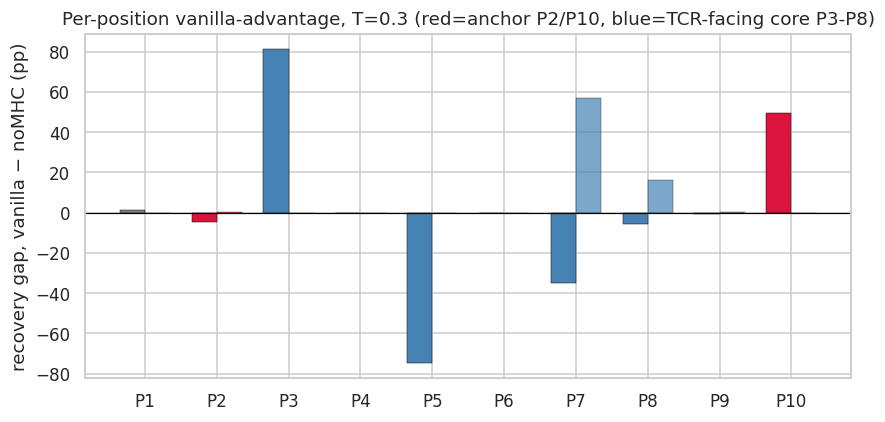

per-crystal, per-anchor breakdown (the pooled mean below can hide a single outlier position):
  6AM5 P2: vanilla-noMHC gap = -4.5pp
  6AM5 P10: vanilla-noMHC gap = +49.5pp
  6AMU P2: vanilla-noMHC gap = +0.2pp
  6AMU P10: vanilla-noMHC gap = +0.0pp

mean vanilla-advantage at anchors (P2,P10), pooled: +11.30pp
mean vanilla-advantage at TCR-facing core (P3-P8): +3.20pp


In [12]:
gap_rows = []
for pid in CRYSTALS:
    pv = perpos_df[(perpos_df.crystal==pid)&(perpos_df.model=="vanilla")][[f"P{i+1}" for i in range(L)]].values[0]
    pn = perpos_df[(perpos_df.crystal==pid)&(perpos_df.model=="noMHC")][[f"P{i+1}" for i in range(L)]].values[0]
    gap_rows.append(pv - pn)
gap = np.array(gap_rows)

fig, ax = plt.subplots(figsize=(8,4))
core = list(range(2,8))  # 0-based P3..P8
for i,pid in enumerate(CRYSTALS):
    colors = ["crimson" if (j+1) in ANCHORS else ("steelblue" if j in core else "grey") for j in range(L)]
    ax.bar(np.arange(L)+i*0.35-0.175, gap[i], width=0.35, color=colors, alpha=.7 if i else 1,
           label=pid, edgecolor="k", linewidth=.3)
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(range(L)); ax.set_xticklabels([f"P{i+1}" for i in range(L)])
ax.set_ylabel("recovery gap, vanilla − noMHC (pp)")
ax.set_title(f"Per-position vanilla-advantage, T={TEMP} (red=anchor P2/P10, blue=TCR-facing core P3-P8)")
plt.tight_layout(); plt.savefig(FIGDIR/"gap_by_position.png", bbox_inches="tight"); plt.show()

anchor_idx = [a-1 for a in ANCHORS]
anchor_gap = gap[:, anchor_idx].mean()
core_gap = gap[:, core].mean()
print("per-crystal, per-anchor breakdown (the pooled mean below can hide a single outlier position):")
for i, pid in enumerate(CRYSTALS):
    for a in ANCHORS:
        print(f"  {pid} P{a}: vanilla-noMHC gap = {gap[i, a-1]:+.1f}pp")
print(f"\nmean vanilla-advantage at anchors (P2,P10), pooled: {anchor_gap:+.2f}pp")
print(f"mean vanilla-advantage at TCR-facing core (P3-P8): {core_gap:+.2f}pp")

## 7. Summary & verdict

In [13]:
summary = {
    "temperature": TEMP,
    "vanilla_complete": bool(status[("vanilla","6AM5")][1] >= NSEQ_TARGET and status[("vanilla","6AMU")][1] >= NSEQ_TARGET),
    "noMHC_status": {pid: status[("noMHC",pid)][2] for pid in CRYSTALS},
}
for pid in CRYSTALS:
    for m in ["vanilla","noMHC"]:
        row = exact_df[(exact_df.crystal==pid)&(exact_df.model==m)]
        if len(row):
            r = row.iloc[0]
            summary[f"{pid}_{m}_mean_identity_pct"] = float(r.mean_identity_pct)
            summary[f"{pid}_{m}_exact_hits"] = int(r.exact_hits)
summary["anchor_gap_pp"] = round(float(anchor_gap), 2)
summary["core_gap_pp"] = round(float(core_gap), 2)

import json; print(json.dumps(summary, indent=2))

exact_df.to_csv(ROOT/"outputs/analysis/nomhc_vs_vanilla_T03_native_recovery.csv", index=False)
perpos_df.to_csv(ROOT/"outputs/analysis/nomhc_vs_vanilla_T03_perposition.csv", index=False)
pd.Series(summary).to_json(ROOT/"outputs/analysis/nomhc_vs_vanilla_T03_summary.json")
print("\nsaved outputs/analysis/nomhc_vs_vanilla_T03_{native_recovery,perposition}.csv + summary.json")

verdict = (
    f"\nVERDICT (T=0.3, numbers as of this run; noMHC campaign may still be in progress, see section 1):\n"
    f"- On the SAME native backbone, vanilla vs noMHC mean-identity gap is {anchor_gap:+.1f}pp at the anchors "
    f"and {core_gap:+.1f}pp at the TCR-facing core.\n"
    "- No cross-temperature (T=0.1) comparisons are drawn here -- see notebook 17 for the T=0.1 equivalent "
    "and compare the two notebooks' numbers side by side if a temperature effect is of interest.\n"
)
gaps_by_crystal = {pid: round(float(exact_df[(exact_df.crystal==pid)&(exact_df.model=='vanilla')].mean_identity_pct.values[0]
                          - exact_df[(exact_df.crystal==pid)&(exact_df.model=='noMHC')].mean_identity_pct.values[0]), 2)
                   for pid in CRYSTALS if len(exact_df[(exact_df.crystal==pid)&(exact_df.model=='noMHC')])}
mixed_sign = len(gaps_by_crystal)==2 and (min(gaps_by_crystal.values()) < 0) and (max(gaps_by_crystal.values()) > 0)
verdict += (
    f"- Exact full-sequence native recovery: " +
    ", ".join(f"{pid}/{m}={int(exact_df[(exact_df.crystal==pid)&(exact_df.model==m)].exact_hits.values[0])}"
              for pid in CRYSTALS for m in ["vanilla","noMHC"] if len(exact_df[(exact_df.crystal==pid)&(exact_df.model==m)])) + "\n"
    f"- Overall-identity gap by crystal: {gaps_by_crystal}"
    + (" -- SIGN FLIPS between crystals, which argues against a general vanilla memorization advantage.\n"
       if mixed_sign else " -- consistent in direction across both crystals.\n")
)
print(verdict)

{
  "temperature": 0.3,
  "vanilla_complete": true,
  "noMHC_status": {
    "6AM5": "complete",
    "6AMU": "complete"
  },
  "6AM5_vanilla_mean_identity_pct": 49.31,
  "6AM5_vanilla_exact_hits": 0,
  "6AM5_noMHC_mean_identity_pct": 48.19,
  "6AM5_noMHC_exact_hits": 0,
  "6AMU_vanilla_mean_identity_pct": 47.01,
  "6AMU_vanilla_exact_hits": 0,
  "6AMU_noMHC_mean_identity_pct": 39.72,
  "6AMU_noMHC_exact_hits": 0,
  "anchor_gap_pp": 11.3,
  "core_gap_pp": 3.2
}

saved outputs/analysis/nomhc_vs_vanilla_T03_{native_recovery,perposition}.csv + summary.json

VERDICT (T=0.3, numbers as of this run; noMHC campaign may still be in progress, see section 1):
- On the SAME native backbone, vanilla vs noMHC mean-identity gap is +11.3pp at the anchors and +3.2pp at the TCR-facing core.
- No cross-temperature (T=0.1) comparisons are drawn here -- see notebook 17 for the T=0.1 equivalent and compare the two notebooks' numbers side by side if a temperature effect is of interest.
- Exact full-sequence n